In [1]:
!pip install pykan --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 8.3 MB/s eta 0:00:00


In [2]:
import numpy as np
from functools import partial
from tqdm import trange
import torch
from torch.utils.data import Dataset
import numpy as np
import scipy.io as sio
import torch.nn as nn
from torch.autograd.functional import jvp
from torch.nn.utils.parametrizations import orthogonal
from torch.utils.data import DataLoader

args={}

# random initial conditions for Lotka-Volterra equation
def generate_random_ics(n_ics=10000, h_min=3, h_max=4.5, canonical=True):
    initial_conditions = []
    for _ in range(n_ics):
        x0 = np.random.uniform(0, 1, size=2)
        if canonical:
            x0 = np.log(x0)
        h = H_lv(x0, canonical=canonical)
        while h < h_min or h > h_max:
            x0 = np.random.uniform(0, 1, size=2)
            if canonical:
                x0 = np.log(x0)
            h = H_lv(x0, canonical=canonical)
        initial_conditions.append(x0)
    return np.array(initial_conditions)


# Hamiltonian for Lotka-Volterra equation
def H_lv(x, a=2/3, b=4/3, c=1.0, d=1.0, canonical=True):
    if canonical:
        return c * np.exp(x[..., 0]) - d * x[..., 0] + b * np.exp(x[..., 1]) - a * x[..., 1]
    else:
        return c * x[..., 0] - d * np.log(x[..., 0]) + b * x[..., 1] - a * np.log(x[..., 1])


# derivative for Lotka-Volterra equation
def lotka_volterra(x, a=2/3, b=4/3, c=1.0, d=1.0, canonical=True):
    dx = np.zeros_like(x)
    if not canonical:
        dx[..., 0] = a * x[..., 0] - b * x[..., 0] * x[..., 1]
        dx[..., 1] = c * x[..., 0] * x[..., 1] - d * x[..., 1]
    else:
        dx[..., 0] = a - b * np.exp(x[..., 1])
        dx[..., 1] = c * np.exp(x[..., 0]) - d
    return dx


# simulate Lotka-Volterra equation from initial conditions
def simulate_lv(x0, dt=0.002, num_steps=10000, a=2/3, b=4/3, c=1.0, d=1.0, canonical=True):
    x = np.zeros((num_steps, *x0.shape))
    dx = np.zeros_like(x)
    x[0] = x0
    update_fn = partial(lotka_volterra, a=a, b=b, c=c, d=d, canonical=canonical)
    # use RK4 integration
    for i in trange(num_steps):
        dx1 = update_fn(x[i])
        dx[i] = dx1
        if i == num_steps - 1:
            break
        k1 = dt * dx1
        dx2 = update_fn(x[i] + 0.5 * k1)
        k2 = dt * dx2
        dx3 = update_fn(x[i] + 0.5 * k2)
        k3 = dt * dx3
        dx4 = update_fn(x[i] + k3)
        k4 = dt * dx4
        x[i + 1] = x[i] + (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return x, dx


def get_lv_data(n_ics, dt=0.002, num_steps=10000, a=2/3, b=4/3, c=1.0, d=1.0, canonical=True):
    ics = generate_random_ics(n_ics, canonical=canonical)
    x, dx = simulate_lv(ics, dt=dt, num_steps=num_steps, a=a, b=b, c=c, d=d, canonical=canonical)
    x = np.transpose(x, (1, 0, 2))  # (n_ics, num_steps, dim)
    dx = np.transpose(dx, (1, 0, 2))  # (n_ics, num_steps, dim)
    return x, dx

In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:

class LotkaVolterraDataset(Dataset):
    def __init__(self, n_timesteps=2, interval=100, mode='train'):
        super().__init__()
        n_ics = 200 if mode == 'train' else 20
        x, dx = get_lv_data(n_ics=n_ics)
        x = torch.FloatTensor(x)
        dx = torch.FloatTensor(dx)

        self.n_timesteps = n_timesteps
        n_ics, n_steps, input_dim = x.shape
        self.n_ics, self.n_steps, self.input_dim = n_ics, n_steps, input_dim
        self.x = []
        self.dx = []
        for i in range(n_ics):
            for j in range(n_steps-n_timesteps*interval):
                self.x.append(x[i, j:j+n_timesteps*interval:interval, :].reshape((n_timesteps, input_dim)))
                self.dx.append(dx[i, j:j+n_timesteps*interval:interval, :].reshape((n_timesteps, input_dim)))

        self.x = torch.stack(self.x)
        self.dx = torch.stack(self.dx)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.dx[idx], self.dx[idx]


In [5]:
train_dataset = LotkaVolterraDataset(mode='train', n_timesteps=2)
val_dataset = LotkaVolterraDataset(mode='val', n_timesteps=2)
args['input_dim'] = train_dataset[0][0].shape[-1]
train_loader = DataLoader(train_dataset, batch_size=8192, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8192, shuffle=False)


100%|█████████▉| 9999/10000 [00:00<00:00, 18231.64it/s]


In [6]:
import torch.nn as nn
from torch.autograd.functional import jvp
from torch.nn.utils.parametrizations import orthogonal


# class Reshape(nn.Module):
#     def __init__(self, *args):
#         super().__init__()
#         self.shape = args

#     def forward(self, x):
#         return x.reshape(self.shape)


# KAN-based Autoencoder - Drop-in replacement for your existing AutoEncoder class
# Make sure to run !pip install pykan first

import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import orthogonal
from kan import KAN # Import the KAN layer

class AutoEncoder(nn.Module):
    '''
    A KAN-based Autoencoder designed as a drop-in replacement.
    
    Arguments:
        (Same as the original MLP AutoEncoder)
    Input:
        x: (batch_size, n_comps, input_dim)
    Output:
        z: (batch_size, n_comps, latent_dim)
        xhat: (batch_size, n_comps, input_dim)
    '''
    def __init__(self, input_dim=2, hidden_dim=5, latent_dim=2, n_layers=3, n_comps=2, batch_norm=True, flatten=False, **kwargs):
        super().__init__()
        
        # Store dimensions for reshaping
        self.input_dim = input_dim
        self.n_comps = n_comps
        
        # KAN layers replace nn.Linear + activation
        # Note: We use n_layers-1 KAN layers and 1 final Linear layer for projection.
        
        # --- Encoder ---
        encoder_kan_layers = []
        # First layer
        encoder_kan_layers.append(KAN([input_dim, hidden_dim]))
        # Hidden layers
        for _ in range(n_layers - 2):
            encoder_kan_layers.append(KAN([hidden_dim, hidden_dim]))

        encoder_kan_layers.append(KAN([hidden_dim, latent_dim]))
        
        self.encoder_kan_stack = nn.Sequential(*encoder_kan_layers)
        
        # Final projection layer remains a standard orthogonal Linear layer
        # This is a hybrid approach to maintain the benefits of orthogonality.
        # self.encoder_final_projection = orthogonal(nn.Linear(hidden_dim, latent_dim))
        
        # Batch Normalization is applied after the final projection
        self.encoder_bn = nn.BatchNorm1d(latent_dim) if batch_norm else nn.Identity()

        # --- Decoder ---
        decoder_kan_layers = []
        # First layer
        decoder_kan_layers.append(KAN([latent_dim, hidden_dim]))
        # Hidden layers
        for _ in range(n_layers - 2):
            decoder_kan_layers.append(KAN([hidden_dim, hidden_dim]))
        decoder_kan_layers.append(KAN([hidden_dim, input_dim]))
        self.decoder_kan_stack = nn.Sequential(*decoder_kan_layers)
        
        # Final output layer
        # self.decoder_final_projection = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        # Store original shape for reshaping the output
        original_shape = x.shape
        
        # Reshape for processing: (batch, n_comps, dim) -> (batch * n_comps, dim)
        x_flat = x.reshape(-1, self.input_dim)
        
        # --- Encoder Pass ---
        # 1. Pass through the main KAN layers
        z_proj = self.encoder_kan_stack(x_flat)
        # 2. Project to latent space with the orthogonal linear layer
        # z_proj = self.encoder_final_projection(h)
        # 3. Apply batch normalization
        z_norm = self.encoder_bn(z_proj)
        
        # --- Decoder Pass ---
        # 1. Pass latent codes through the main KAN decoder layers
        xhat_flat = self.decoder_kan_stack(z_norm)
        # 2. Project back to the original data dimension
        # xhat_flat = self.decoder_final_projection(h_dec)
        
        # Reshape outputs back to the original component structure
        z = z_norm.reshape(original_shape[0], self.n_comps, -1)
        xhat = xhat_flat.reshape(original_shape)
        
        return z, xhat

    def decode(self, z):
        # z has shape (batch, n_comps, latent_dim)
        original_shape = z.shape
        
        # Reshape for processing: (batch, n_comps, dim) -> (batch * n_comps, dim)
        z_flat = z.reshape(-1, original_shape[-1])
        
        # Pass through decoder
        xhat_flat = self.decoder_kan_stack(z_flat)
        # xhat_flat = self.decoder_final_projection(h_dec)
        
        # Reshape back to the component structure with the original input dimension
        xhat = xhat_flat.reshape(original_shape[0], self.n_comps, self.input_dim)
        
        return xhat

# Note: The Reshape class is no longer needed inside the AutoEncoder,
# as reshaping is now handled explicitly in the forward/decode methods.
class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args
    def forward(self, x):
        return x.reshape(self.shape)


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LieGenerator(nn.Module):
    def __init__(self, **kwargs):
        super(LieGenerator, self).__init__()
        self.threshold = 0.3
        self.keep_center = 0
        self.construct_group_representation()
        self.masks = [mask.to(device) if mask is not None else None for mask in self.masks]

    def construct_group_representation(self):
        # analyze the repr string
        repr = (2,1,2)

        # repr is a tuple of (N1, N2, N3) indicating N1 N3-dim vectors acted on by N2-dim Lie group, (N1, STR) specifying the group info, or (N1,) indicating N1 scalars
        self.Li = nn.ParameterList()
        self.masks = []  # mask for sequential thresholding
        self.n_comps = []
        self.n_channels = []
        self.learnable = []
        self.n_dims = 0
        n_comps, n_channels, n_dims = repr
        n_comps, n_channels, n_dims = int(n_comps), int(n_channels), int(n_dims)
        Li = nn.Parameter(torch.tensor([[[0.0,1.0],[-1.0,0.0]]]))
        # Li = nn.Parameter(torch.randn(n_channels, n_dims, n_dims))
        mask = torch.ones_like(Li)
        self.Li.append(Li)
        self.masks.append(mask)
        self.n_comps.append(n_comps)
        self.n_channels.append(n_channels)
        self.learnable.append(True)
        self.n_dims += n_dims * n_comps
        print(f'Constructed Lie group representation with {self.n_dims} latent dimensions.')

    def channel_corr(self):
        s = 0.0
        for Li in self.Li:
            norm = torch.einsum('kdf,kdf->k', Li, Li)
            Li_N = Li / (torch.sqrt(norm).unsqueeze(-1).unsqueeze(-1) + 1e-6)
            s += torch.sum(torch.abs(torch.triu(torch.einsum('bij,cij->bc', Li_N, Li_N), diagonal=1)))
        return s

    def forward(self, x):  # random transformation on x
        # x: (batch_size, *, n_dims)
        # normalize x to have zero mean
        if not self.keep_center:
            x_mean = torch.mean(x, dim=list(range(len(x.shape)-1)), keepdim=True)
            x = x - x_mean
        batch_size = x.shape[0]
        output_shape = x.shape
        if len(x.shape) == 3:
            x = x.reshape(batch_size, -1)
        # z = self.sample_coefficient(batch_size, x.device)
        # g_z = torch.matrix_exp(torch.einsum('bj,jkl->bkl', z, self.getLi()))
        g_z = self.sample_group_element(batch_size, x.device)
        x_t = torch.einsum('bij,bj->bi', g_z, x)
        x_t = x_t.reshape(output_shape)
        if not self.keep_center:
            x_t = x_t + x_mean
        return x_t

    def set_threshold(self, threshold):
        # relative to max in each channel
        for Li, mask in zip(self.Li, self.masks):
            if mask is None:
                continue
            max_chval = torch.amax(torch.abs(Li), dim=(1, 2), keepdim=True)
            # mask.data = torch.logical_and(torch.abs(Li) > threshold * max_chval, mask).float()
            mask.data = (torch.abs(Li) > threshold * max_chval).float()

    def sample_group_element(self, batch_size, device):
        start_dim = 0
        g = []
        for Li, mask, n_comps, n_channels, learnable in zip(self.Li, self.masks, self.n_comps, self.n_channels, self.learnable):
            if learnable and mask is not None:
                Li = Li * mask
            z = self.sample_coefficient(batch_size, n_channels)
            g_z = torch.matrix_exp(torch.einsum('bj,jkl->bkl', z, Li))
            for _ in range(n_comps):
                end_dim = start_dim + g_z.shape[1]
                g_z_padded = F.pad(g_z, (start_dim, self.n_dims - end_dim, start_dim, self.n_dims - end_dim))
                g.append(g_z_padded)
                start_dim = end_dim
        g = torch.stack(g, dim=1)
        g = torch.sum(g, dim=1)
        return g

    def sample_coefficient(self, batch_size, n_channels):
        z = torch.randn(batch_size, n_channels, device=device)
        return z

    def transform(self, g_z, x, tp):
        return torch.einsum('bjk,bk->bj', g_z, x)
        # if tp == 'vector':
        #     return torch.einsum('bjk,btk->btj', g_z, x)
        # elif tp == 'scalar':
        #     return x
        # elif tp == 'grid':
        #     grid = F.affine_grid(g_z[:, :-1], x.shape)
        #     return F.grid_sample(x, grid)

    def getLi(self):
        # convert ParameterList to list of tensors
        return [Li * mask if learnable else Li
                for Li, mask, learnable in zip(self.Li, self.masks, self.learnable)]


class Discriminator(nn.Module):
    def __init__(self, latent_dim=2, n_comps=2, hidden_dim=512, n_layers=5, activation='ReLU'):
        super(Discriminator, self).__init__()
        self.input_dim = latent_dim * n_comps
        self.model = nn.Sequential(
            nn.Linear(self.input_dim, hidden_dim),
            getattr(nn, activation)(),
            *[nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                getattr(nn, activation)(),
            ) for _ in range(n_layers-1)],
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),
        )

    def forward(self, z, y=None, x=None):
        # z: latent representation; y: invariant label; x: original input
        z = z.reshape(z.shape[0], -1)
        validity = self.model(z)
        return validity

In [8]:
autoencoder = AutoEncoder().to(device)
discriminator = Discriminator().to(device)
generator = LieGenerator().to(device)

checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
Constructed Lie group representation with 4 latent dimensions.


In [9]:
import torch
import torch.nn as nn
import numpy as np
import os
from tqdm.auto import tqdm

def train_lassi(
    autoencoder, discriminator, generator, train_loader, test_loader,
    num_epochs=30, lr_ae=0.001, lr_d=0.001, lr_g=0.001, w_recon=1.0, w_gan=1.0, w_reg=0.1,gan_st_freq=5, gan_st_thresh=0.3, log_interval=1
):
    optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=lr_ae)
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=lr_d)
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr_g)
    adversarial_loss = torch.nn.BCELoss()
    recon_loss = torch.nn.MSELoss()

    for epoch in range(num_epochs):
        # torch.autograd.set_detect_anomaly(True)
        running_losses = [[], [], [], [], [], [], [], [], [], []]
        autoencoder.train()
        discriminator.train()
        generator.train()
        for i, (x, dx, y) in tqdm(enumerate(train_loader),total = len(train_loader)):
            x = x.to(device)
            bs = x.shape[0]

            # Adversarial ground truths
            valid = torch.ones((bs, 1)).to(device)
            fake = torch.zeros((bs, 1)).to(device)

            # Reconstruction loss
            z, xhat = autoencoder(x)
            loss_ae = w_recon * recon_loss(xhat, x)
            running_losses[0].append(loss_ae.item() / w_recon)
            loss_ae_rel = loss_ae / recon_loss(x, torch.zeros_like(x))
            running_losses[5].append(loss_ae_rel.item() / (w_recon + 1e-6))
            loss = loss_ae

            # Generator loss
            zt = generator(z)  # transformed latent space representation
            d_fake = discriminator(zt)
            loss_g = w_gan * adversarial_loss(d_fake, valid)
            running_losses[1].append(loss_g.item() / (w_gan + 1e-6))
            loss = loss + loss_g
            loss_g_reg = torch.abs(nn.CosineSimilarity(dim=-1)(zt, z).mean())
            running_losses[2].append(loss_g_reg.item())
            loss = loss + w_reg * loss_g_reg

            # Discriminator loss
            z_detached = z.detach()
            zt_detached = zt.detach()
            loss_d_real = adversarial_loss(discriminator(z_detached), valid)
            loss_d_fake = adversarial_loss(discriminator(zt_detached), fake)
            running_losses[3].append(loss_d_real.item())
            running_losses[4].append(loss_d_fake.item())
            loss_d = (loss_d_real + loss_d_fake) / 2
            loss = loss + loss_d

            optimizer_ae.zero_grad()
            optimizer_d.zero_grad()
            optimizer_g.zero_grad()
            loss.backward()
            optimizer_ae.step()
            optimizer_d.step()
            # optimizer_g.step()
        # sequential thresholding
        if gan_st_freq > 0 and (epoch + 1) % gan_st_freq == 0:
            generator.set_threshold(gan_st_thresh)

        if (epoch + 1) % log_interval == 0:
            print(f'Epoch {epoch}, loss_ae: {np.mean(running_losses[0]):.4f}, loss_g: {np.mean(running_losses[1]):.4f}, loss_g_reg: {np.mean(running_losses[2]):.4f}, loss_d_real: {np.mean(running_losses[3]):.4f}, loss_d_fake: {np.mean(running_losses[4]):.4f}, loss_ae_rel: {np.mean(running_losses[5]):.4f}')
            autoencoder.eval()
            discriminator.eval()
            generator.eval()
            with torch.no_grad():
                running_losses = [[], [], [], [], [], [], []]
                for i, (x, dx, y) in enumerate(test_loader):
                    x = x.to(device)
                    dx = dx.to(device)
                    bs = x.shape[0]
                    valid = torch.ones((bs, 1)).to(device)
                    fake = torch.zeros((bs, 1)).to(device)
                    z, xhat = autoencoder(x)
                    zt = generator(z)
                    xt = autoencoder.decode(zt)
                    d_fake = discriminator(zt)
                    d_real = discriminator(z)
                    loss_ae = recon_loss(xhat, x)
                    loss_ae_rel = loss_ae / recon_loss(x, torch.zeros_like(x))
                    loss_g = adversarial_loss(d_fake, valid)
                    loss_d_real = adversarial_loss(d_real, valid)
                    loss_d_fake = adversarial_loss(d_fake, fake)
                    running_losses[0].append(loss_ae.item())
                    running_losses[1].append(loss_g.item())
                    running_losses[2].append(loss_d_real.item())
                    running_losses[3].append(loss_d_fake.item())
                    running_losses[4].append(loss_ae_rel.item())

                print(f'Epoch {epoch} test, loss_ae: {np.mean(running_losses[0]):.4f}, loss_g: {np.mean(running_losses[1]):.4f}, loss_d_real: {np.mean(running_losses[2]):.4f}, loss_d_fake: {np.mean(running_losses[3]):.4f}, loss_ae_rel: {np.mean(running_losses[4]):.4f}')
                print(generator.getLi())


In [10]:
autoencoder = AutoEncoder().to(device)
discriminator = Discriminator().to(device)
generator = LieGenerator().to(device)
train_lassi(autoencoder, discriminator, generator, train_loader, val_loader)

checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
checkpoint directory created: ./model
saving model version 0.0
Constructed Lie group representation with 4 latent dimensions.


  0%|          | 0/240 [00:00<?, ?it/s]

Epoch 0, loss_ae: 2.3655, loss_g: 0.3562, loss_g_reg: 0.6033, loss_d_real: 0.1372, loss_d_fake: 1.2747, loss_ae_rel: 0.6039
Epoch 0 test, loss_ae: 0.9273, loss_g: 0.3502, loss_d_real: 0.1479, loss_d_fake: 1.2926, loss_ae_rel: 0.2360
[tensor([[[ 0.,  1.],
         [-1.,  0.]]], device='cuda:0')]


  0%|          | 0/240 [00:00<?, ?it/s]

Epoch 1, loss_ae: 0.3294, loss_g: 0.3400, loss_g_reg: 0.6234, loss_d_real: 0.1613, loss_d_fake: 1.3049, loss_ae_rel: 0.0841
Epoch 1 test, loss_ae: 0.0398, loss_g: 0.3461, loss_d_real: 0.1513, loss_d_fake: 1.2920, loss_ae_rel: 0.0088
[tensor([[[ 0.,  1.],
         [-1.,  0.]]], device='cuda:0')]


...

Epoch 27, loss_ae: 0.0057, loss_g: 0.3479, loss_g_reg: 0.4614, loss_d_real: 0.1413, loss_d_fake: 1.2904, loss_ae_rel: 0.0015
Epoch 27 test, loss_ae: 0.0067, loss_g: 0.3457, loss_d_real: 0.1534, loss_d_fake: 1.2995, loss_ae_rel: 0.0017
[tensor([[[ 0.,  1.],
         [-1.,  0.]]], device='cuda:0')]


  0%|          | 0/240 [00:00<?, ?it/s]

Epoch 28, loss_ae: 0.0057, loss_g: 0.3485, loss_g_reg: 0.4759, loss_d_real: 0.1401, loss_d_fake: 1.2874, loss_ae_rel: 0.0015
Epoch 28 test, loss_ae: 0.0161, loss_g: 0.3395, loss_d_real: 0.1477, loss_d_fake: 1.3157, loss_ae_rel: 0.0039
[tensor([[[ 0.,  1.],
         [-1.,  0.]]], device='cuda:0')]


  0%|          | 0/240 [00:00<?, ?it/s]

Epoch 29, loss_ae: 0.0054, loss_g: 0.3478, loss_g_reg: 0.4909, loss_d_real: 0.1413, loss_d_fake: 1.2884, loss_ae_rel: 0.0014
Epoch 29 test, loss_ae: 0.0079, loss_g: 0.3495, loss_d_real: 0.1395, loss_d_fake: 1.2846, loss_ae_rel: 0.0018
[tensor([[[ 0.,  1.],
         [-1.,  0.]]], device='cuda:0')]



--- Generating Visualization from Validation Set ---
Creating a fixed group transformation element...
torch.Size([4, 4])
Aggregating data and applying fixed transformation...


Processing validation set:   0%|          | 0/24 [00:00<?, ?it/s]

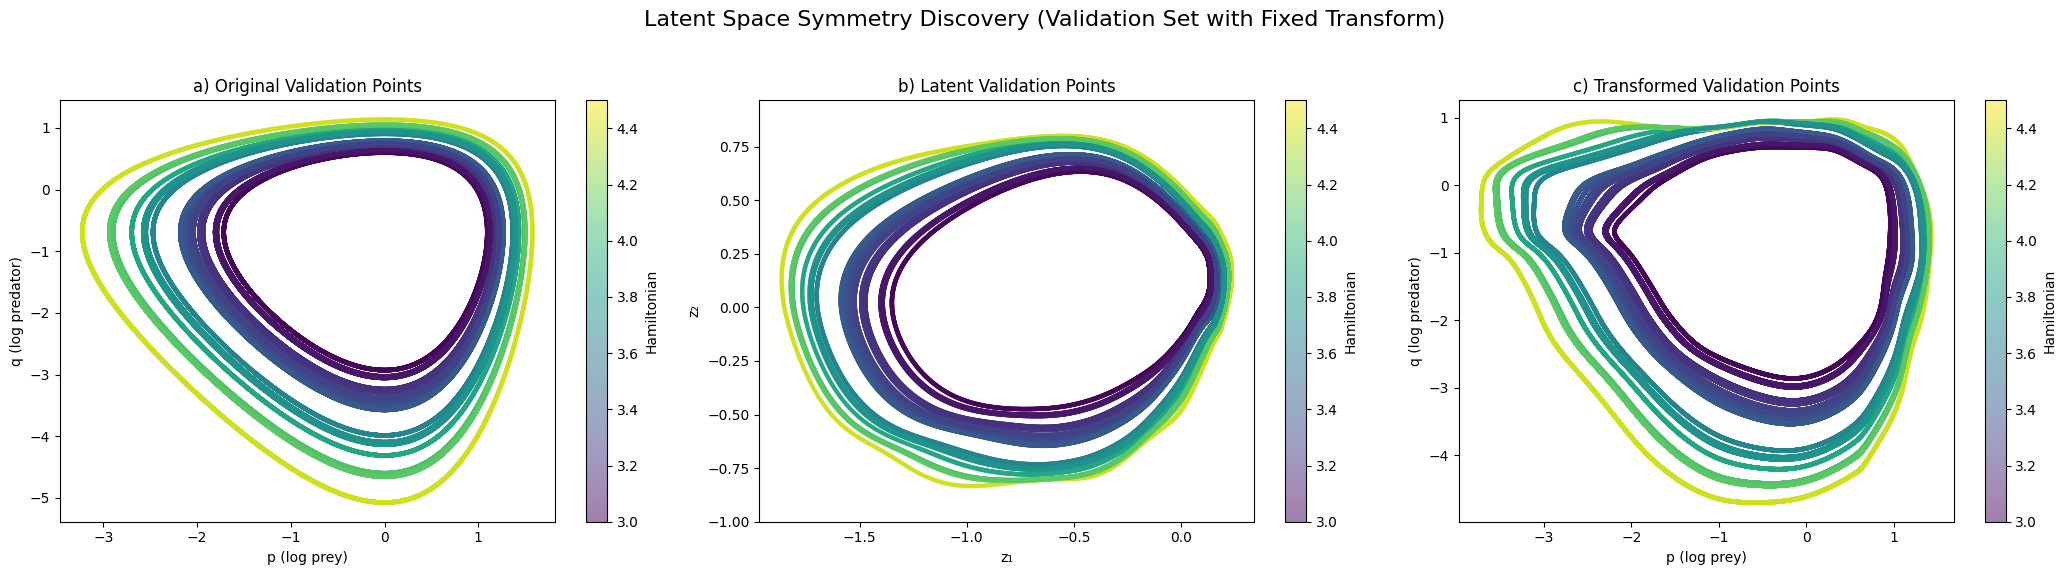


Final Discovered Lie Algebra Basis L:
 [[[ 0.  1.]
  [-1.  0.]]]


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.notebook import tqdm

# =============================================================================
# 6. VISUALIZATION AND ANALYSIS (Using val_loader with a Fixed Group Element)
# =============================================================================
print("\n--- Generating Visualization from Validation Set ---")

# Put models in evaluation mode
autoencoder.eval()
generator.eval()

# --- Step 1: Pre-calculate a SINGLE, FIXED group transformation element ---
print("Creating a fixed group transformation element...")
with torch.no_grad():
    # We will manually replicate the generator's logic for a single element
    lie_algebra_basis = generator.getLi()[0] # getLi() returns a list, we need the tensor
    
    # Sample a single large coefficient for a visible rotation
    coeffs = torch.randn(1, 1, device=device) * 1.0 
    
    # Create the single 4x4 transformation matrix
    g_transform = generator.sample_group_element(batch_size=1, device=device)
    # The generator's forward pass creates a random transform per batch item.
    # To get a single fixed transform, we can call its internal method for a batch of 1.
    g_transform = g_transform.squeeze(0) # Remove the batch dimension -> [4, 4]

print(g_transform.shape)
    
# --- Step 2: Aggregate all points from the val_loader ---
print("Aggregating data and applying fixed transformation...")
x_original_list = []
z_latent_list = []
x_transformed_list = []
hamiltonians_list = []

with torch.no_grad():
    for x_batch, _, _ in tqdm(val_loader, desc="Processing validation set"):
        x_batch = x_batch.to(device)
        
        # Get latent representation
        z_latent_batch, _ = autoencoder(x_batch) # Shape: [batch_size, 2, 2]
        
        # --- Apply the FIXED g_transform to this batch ---
        # Reshape for matrix multiplication: [batch_size, 2, 2] -> [batch_size, 4]
        z_latent_flat = z_latent_batch.reshape(x_batch.shape[0], -1)
        # Apply transform: (batch_size, 4) @ (4, 4) -> (batch_size, 4)
        z_transformed_flat = z_latent_flat @ g_transform.T
        # Reshape back for the decoder
        z_transformed_batch = z_transformed_flat.reshape(x_batch.shape[0], 2, 2)

        # Decode the transformed points
        x_transformed_batch = autoencoder.decode(z_transformed_batch)
        
        # Store the results
        x_original_list.append(x_batch.cpu())
        z_latent_list.append(z_latent_batch.cpu())
        x_transformed_list.append(x_transformed_batch.cpu())
        hamiltonians_list.append(H_lv(x_batch.cpu().numpy()))

# Concatenate all batches into single large tensors
x_original_all = torch.cat(x_original_list, dim=0)
z_latent_all = torch.cat(z_latent_list, dim=0)
x_transformed_all = torch.cat(x_transformed_list, dim=0)
hamiltonians_all = np.concatenate(hamiltonians_list, axis=0)

# --- Step 3: Reshape data for plotting ---
# Data is shape (N_samples, 2, 2). We plot the first component (:, 0, :)
# and the second component (:, 1, :)
x_original_comp1 = x_original_all[:, 0, :].numpy()
z_latent_comp1 = z_latent_all[:, 0, :].numpy()
x_transformed_comp1 = x_transformed_all[:, 0, :].numpy()
hamiltonians_comp1 = hamiltonians_all[:, 0]

# --- Step 4: Generate the 3-panel plot ---
fig, axs = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle("Latent Space Symmetry Discovery (Validation Set with Fixed Transform)", fontsize=16)
vmin, vmax = 3, 4.5 # Hamiltonian range

# Panel (a): Original Validation Points (Component 1)
axs[0].set_title("a) Original Validation Points")
im = axs[0].scatter(x_original_comp1[:, 0], x_original_comp1[:, 1], c=hamiltonians_comp1,
                   cmap='viridis', s=5, vmin=vmin, vmax=vmax, alpha=0.5)
axs[0].set_xlabel("p (log prey)"); axs[0].set_ylabel("q (log predator)")
fig.colorbar(im, ax=axs[0], label='Hamiltonian')

# Panel (b): Latent Validation Points (Component 1)
axs[1].set_title("b) Latent Validation Points")
im = axs[1].scatter(z_latent_comp1[:, 0], z_latent_comp1[:, 1], c=hamiltonians_comp1,
                   cmap='viridis', s=5, vmin=vmin, vmax=vmax, alpha=0.5)
axs[1].set_xlabel("z₁"); axs[1].set_ylabel("z₂")
axs[1].axis('equal')
fig.colorbar(im, ax=axs[1], label='Hamiltonian')

# Panel (c): Transformed Validation Points (Component 1)
axs[2].set_title("c) Transformed Validation Points")
im = axs[2].scatter(x_transformed_comp1[:, 0], x_transformed_comp1[:, 1], c=hamiltonians_comp1,
                   cmap='viridis', s=5, vmin=vmin, vmax=vmax, alpha=0.5)
axs[2].set_xlabel("p (log prey)"); axs[2].set_ylabel("q (log predator)")
fig.colorbar(im, ax=axs[2], label='Hamiltonian')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Also print the final learned Lie Algebra for inspection
print("\nFinal Discovered Lie Algebra Basis L:\n", generator.getLi()[0].detach().cpu().numpy())